**Financial Fraud Detection using Logistic Regression**

**Introduction:**

Financial fraud detection is a critical application of machine learning in the banking and finance industry. Fraudulent transactions can lead to significant financial losses, making it essential to identify them accurately and efficiently. Logistic regression is a simple yet powerful classification algorithm that can be used to detect fraudulent activities by learning patterns from historical transaction data. In this code, we'll preprocess transaction data, train a logistic regression model, and evaluate its performance using metrics like precision, recall, and F1-score, which are crucial for handling imbalanced datasets common in fraud detection.

In [1]:
# Financial Fraud Detection with Logistic Regression

# Step 1: Install and import required libraries
!pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE  # Handle class imbalance

In [3]:
# Step 2: Load and explore the dataset
# Using the Kaggle Credit Card Fraud Detection dataset (publicly available)
# Download the dataset from: https://www.kaggle.com/mlg-ulb/creditcardfraud
# Upload 'creditcard.csv' to Colab when prompted
from google.colab import files
uploaded = files.upload()

# Load data into a DataFrame
df = pd.read_csv('creditcard.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution (0: Legitimate, 1: Fraud):")
print(df['Class'].value_counts())


Saving creditcard.csv to creditcard.csv
Dataset Shape: (284807, 31)

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.

In [4]:
# Step 3: Data preprocessing
# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Scale the 'Amount' and 'Time' features (other features are already PCA-transformed)
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time_Scaled'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df.drop(['Time', 'Amount'], axis=1, inplace=True)


Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [5]:
# Step 4: Handle class imbalance using SMOTE
X = df.drop('Class', axis=1)
y = df['Class']

# Split data before oversampling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Apply SMOTE only to the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nTraining set class distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())



Training set class distribution after SMOTE:
Class
0    199020
1    199020
Name: count, dtype: int64


In [6]:
# Step 5: Train logistic regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=1000, random_state=42)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443


Confusion Matrix:
[[83376  1919]
 [   18   130]]

ROC-AUC Score: 0.9660


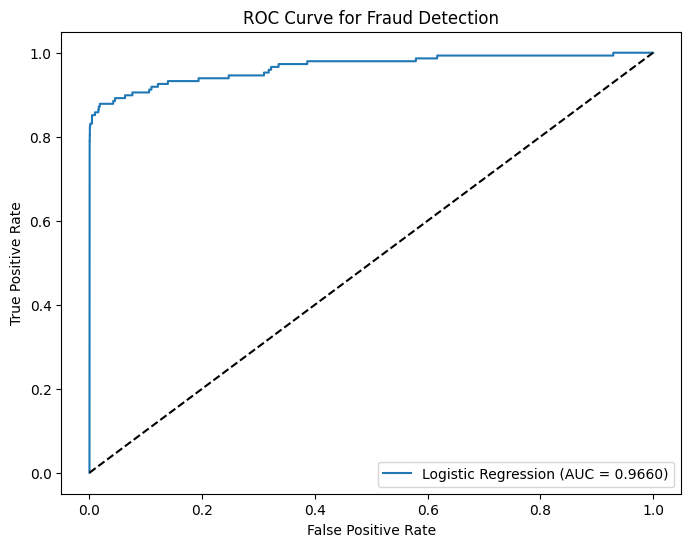

In [7]:
# Step 6: Evaluate the model
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ROC-AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC Score: {auc_score:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Fraud Detection')
plt.legend()
plt.show()


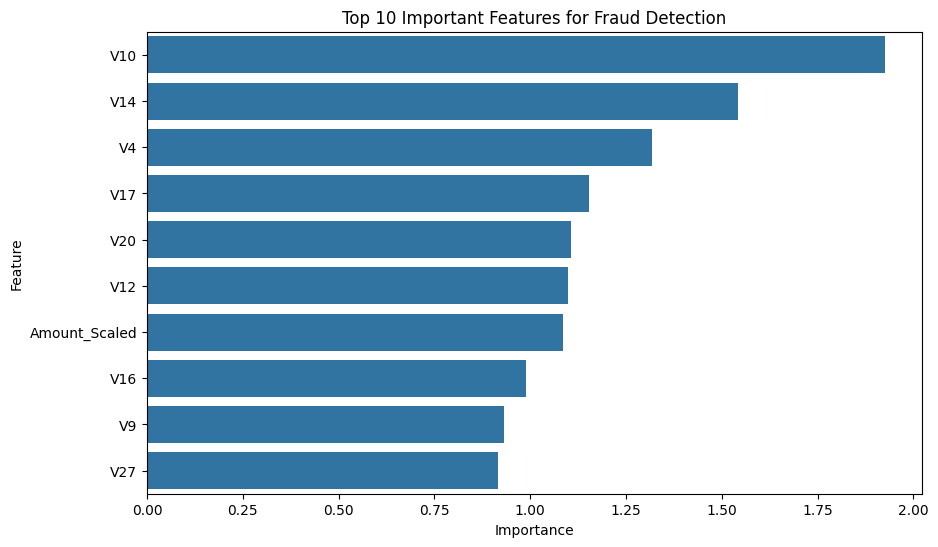

In [8]:
# Step 7: Feature importance analysis
importance = np.abs(model.coef_[0])
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Top 10 Important Features for Fraud Detection')
plt.show()

**Key Steps Explained:**

* Data Loading: Uses a popular credit card fraud dataset from Kaggle.

* Preprocessing: Scales numerical features (Time and Amount) to normalize their ranges.

* Handling Imbalance: Applies SMOTE to oversample the minority class (fraud cases) in the training set.

* Model Training: Trains a logistic regression model on the balanced data.

* Evaluation: Uses metrics like precision, recall, and ROC-AUC to assess performance, critical for imbalanced datasets.

* Visualization: Includes ROC curves and feature importance plots for interpretability.

**Notes:**

* Replace the dataset with your own data if needed (ensure it has similar features).

* Adjust hyperparameters (e.g., max_iter in logistic regression) for optimization.

* For larger datasets, consider using sampling techniques like Random Undersampling or advanced models like Random Forests.

This code provides a foundational framework for fraud detection and can be extended with more sophisticated techniques as needed.